In [1]:
# Preparacion del notebook

import sys
sys.path.append("..")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import cargar_enemdu, mediana_ponderada
from src.features import agregar_variables

df = agregar_variables(cargar_enemdu())
os.makedirs("../reports/figures", exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
FUENTE = "Fuente: INEC, ENEMDU I Trimestre 2026. Cálculos propios, ponderados con fexp."

In [2]:
# Comprobacion de la funcion

ing = df[df["condact"].between(1, 6) & (df["ingrl"] > 0)]
print(ing.groupby("sexo").apply(lambda s: mediana_ponderada(s["ingrl"], s["fexp"])))

sexo
Hombre    430.0
Mujer     350.0
dtype: float64


condact
Empleo adecuado                   35.7
Subempleo                         18.4
Otro empleo no pleno              32.6
No remunerado / no clasificado     9.9
Desempleo                          3.4
Name: fexp, dtype: float64


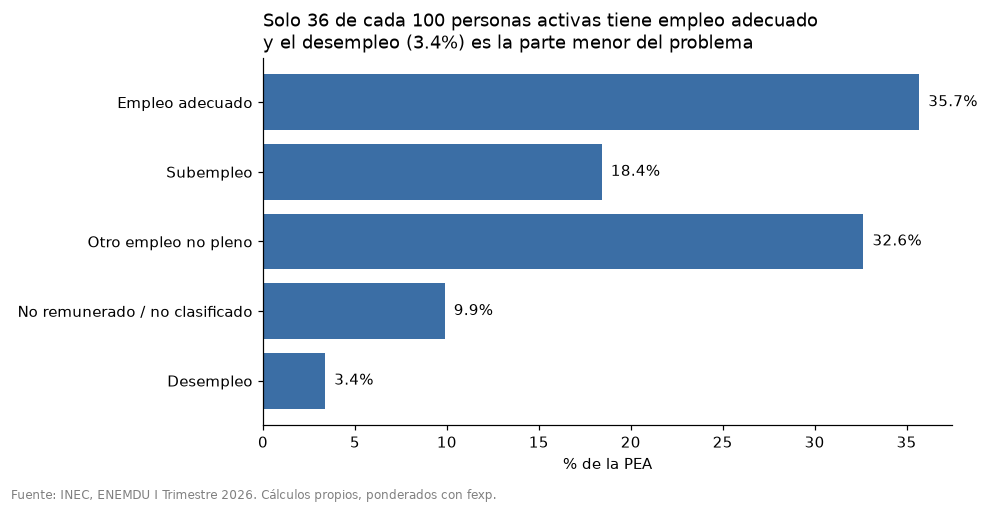

In [3]:
# Grafico 1: de que esta hecha la PEA

mapa = {1: "Empleo adecuado", 2: "Subempleo", 3: "Subempleo",
        4: "Otro empleo no pleno",
        5: "No remunerado / no clasificado", 6: "No remunerado / no clasificado",
        7: "Desempleo", 8: "Desempleo"}
orden = ["Empleo adecuado", "Subempleo", "Otro empleo no pleno",
         "No remunerado / no clasificado", "Desempleo"]

pea = df[df["condact"].between(1, 8)]
comp = pea.groupby(pea["condact"].map(mapa))["fexp"].sum()
comp = (100 * comp / comp.sum()).reindex(orden)
print(comp.round(1))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(comp.index[::-1], comp.values[::-1], color="#3b6ea5")
for y, v in enumerate(comp.values[::-1]):
    ax.text(v + 0.5, y, f"{v:.1f}%", va="center")
ax.set_xlabel("% de la PEA")
ax.set_title(f"Solo {comp['Empleo adecuado']:.0f} de cada 100 personas activas tiene empleo adecuado\n"
             f"y el desempleo ({comp['Desempleo']:.1f}%) es la parte menor del problema", loc="left")
fig.text(0.01, -0.02, FUENTE, fontsize=8, color="gray")
fig.tight_layout()
fig.savefig("../reports/figures/01_composicion_pea.png", dpi=150, bbox_inches="tight")

Informalidad nacional: 53.5
sexo    Hombre  Mujer
zona                 
Urbana    44.7   37.2
Rural     73.5   78.9


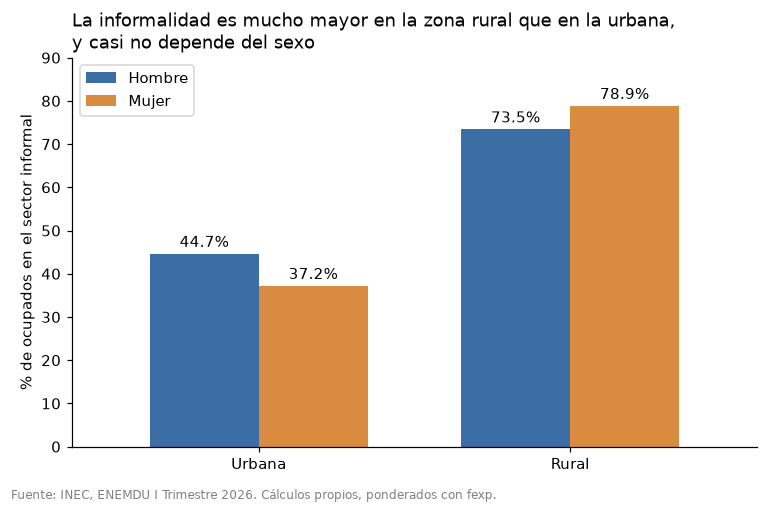

In [4]:
# Informalidad por zona y sexo

oc = df[df["informal"].notna()].copy()
oc["w_inf"] = oc["informal"] * oc["fexp"]

print("Informalidad nacional:", round(100 * oc["w_inf"].sum() / oc["fexp"].sum(), 1))   # debe dar 53.5

g = oc.groupby(["zona", "sexo"])[["w_inf", "fexp"]].sum()
res = (100 * g["w_inf"] / g["fexp"]).unstack().reindex(["Urbana", "Rural"])
print(res.round(1))

ax = res.plot(kind="bar", figsize=(7, 4.5), color=["#3b6ea5", "#d98c3f"], rot=0, width=0.7)
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=2)
ax.set_ylabel("% de ocupados en el sector informal")
ax.set_xlabel("")
ax.set_ylim(0, 90)
ax.set_title("La informalidad es mucho mayor en la zona rural que en la urbana,\n"
             "y casi no depende del sexo", loc="left")
ax.legend(title="")
plt.gcf().text(0.01, -0.02, FUENTE, fontsize=8, color="gray")
plt.tight_layout()
plt.savefig("../reports/figures/02_informalidad_zona_sexo.png", dpi=150, bbox_inches="tight")

sexo
Hombre    430.0
Mujer     350.0
dtype: float64 
razón: 0.814


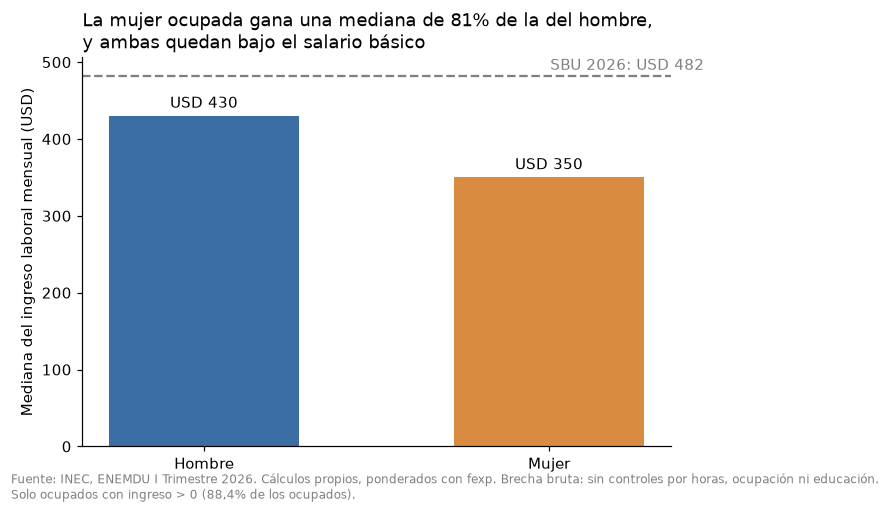

In [5]:
# Brecha de ingresos por sexo

SBU = 482
ing = df[df["condact"].between(1, 6) & (df["ingrl"] > 0)]
med = ing.groupby("sexo").apply(lambda s: mediana_ponderada(s["ingrl"], s["fexp"]))
ratio = med["Mujer"] / med["Hombre"]
print(med, f"\nrazón: {ratio:.3f}")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
barras = ax.bar(med.index, med.values, color=["#3b6ea5", "#d98c3f"], width=0.55)
ax.bar_label(barras, fmt="USD %.0f", padding=3)
ax.axhline(SBU, color="gray", linestyle="--")
ax.text(1.45, SBU + 8, f"SBU 2026: USD {SBU}", ha="right", color="gray")
ax.set_ylabel("Mediana del ingreso laboral mensual (USD)")
ax.set_title(f"La mujer ocupada gana una mediana de {ratio:.0%} de la del hombre,\n"
             "y ambas quedan bajo el salario básico", loc="left")
fig.text(0.01, -0.02, FUENTE + " Brecha bruta: sin controles por horas, ocupación ni educación.\n"
         "Solo ocupados con ingreso > 0 (88,4% de los ocupados).", fontsize=8, color="gray")
fig.tight_layout()
fig.savefig("../reports/figures/03_brecha_ingreso_sexo.png", dpi=150, bbox_inches="tight")